# 3 — The Reframing That Worked: Temporal Dynamics of TDA Descriptors

Not "what does today's persistence diagram look like" but "how has it
been *moving*" -- rolling statistics, exponentially-weighted trends,
autocorrelation, and genuine trajectory descriptors (path length,
straightness, local coherence of recent motion) computed from the same
underlying diagrams that failed as static snapshots in notebook 2.

Four independent feature families were built this way, each following
the same pre-committed, placebo-tested discipline, and each confirmed
against the Arm A financial baseline. This notebook loads and presents
all four.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA = Path.cwd().parent / "data" / "processed" / "backtest_results"

ARMS = {
    "arm_d": ("Scalar dynamics", "rolling/EWM stats of core topological descriptors"),
    "arm_e": ("Trajectory descriptors", "path length, straightness, local coherence of the diagram's motion"),
    "arm_g": ("Curvature + autocorrelation", "directional change and self-correlation of the trajectory"),
    "arm_i": ("Exhaustive dynamic sweep", "the same toolkit applied to every remaining untreated descriptor"),
}


## The four confirmed findings, on `vol_regime_h7`, RandomForest

Each row below is independently re-derived from its own saved comparison
file (not just a summary table) -- same walk-forward validation,
paired-bootstrap significance, FDR correction, and a placebo control
(shuffle the new columns' row order, breaking their real temporal
alignment while preserving each column's own distribution; rerun the
whole comparison -- what fraction of the improvement survives shuffling
is model capacity, what doesn't is genuine signal).


In [2]:
rows = []
for arm, (name, desc) in ARMS.items():
    mc = pd.read_parquet(DATA / f"model_comparison_results_{arm}.parquet")
    row = mc[(mc["target"] == "vol_regime_h7") & (mc["model"] == "random_forest")].iloc[0]
    placebo = pd.read_csv(DATA / f"placebo_{arm}_best.csv")
    real_auc = row["metric_b"]
    base_auc = row["metric_a"]
    beat = int((real_auc > placebo["placebo_metric"]).sum())
    capacity_pct = 100 * (placebo["placebo_metric"].mean() - base_auc) / (real_auc - base_auc)
    rows.append({
        "feature family": name,
        "what it captures": desc,
        "Arm A AUC": round(base_auc, 4),
        "+ TDA AUC": round(real_auc, 4),
        "gain": f"+{row['observed_diff']:.4f}",
        "FDR p": round(row["p_value_fdr"], 4),
        "beats N/20 shuffles": f"{beat}/{len(placebo)}",
        "% genuine (not capacity)": f"{100 - capacity_pct:.0f}%",
    })
summary = pd.DataFrame(rows).set_index("feature family")
summary


,what it captures,Arm A AUC,+ TDA AUC,gain,FDR p,beats N/20 shuffles,% genuine (not capacity)
feature family,,,,,,,
Scalar dynamics,rolling/EWM stats of core topological descriptors,0.4796,0.5723,+0.0927,0.000,20/20,106%
Trajectory descriptors,"path length, straightness, local coherence of ...",0.4796,0.5307,+0.0511,0.012,20/20,80%
Curvature + autocorrelation,directional change and self-correlation of the...,0.4796,0.5557,+0.0761,0.000,20/20,89%
Exhaustive dynamic sweep,the same toolkit applied to every remaining un...,0.4796,0.5659,+0.0862,0.000,20/20,93%


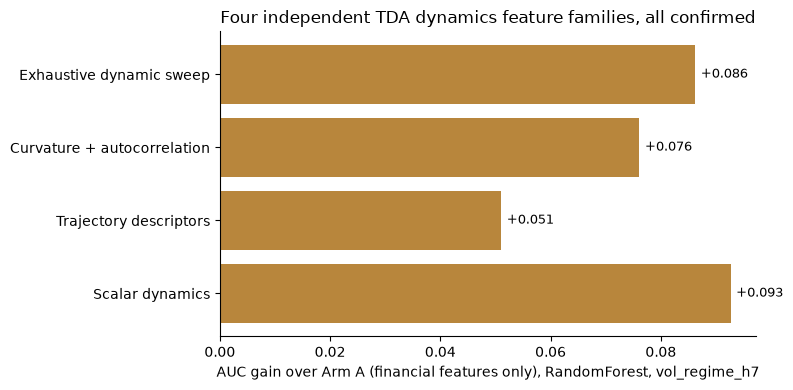

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(ARMS.keys())
gains = [pd.read_parquet(DATA / f"model_comparison_results_{a}.parquet")
         .pipe(lambda d: d[(d["target"] == "vol_regime_h7") & (d["model"] == "random_forest")]["observed_diff"].iloc[0])
         for a in names]
labels = [ARMS[a][0] for a in names]
colors = ["#B8863C"] * len(names)
bars = ax.barh(labels, gains, color=colors)
for bar, g in zip(bars, gains):
    ax.text(g + 0.001, bar.get_y() + bar.get_height() / 2, f"+{g:.3f}", va="center", fontsize=9)
ax.set_xlabel("AUC gain over Arm A (financial features only), RandomForest, vol_regime_h7")
ax.set_title("Four independent TDA dynamics feature families, all confirmed")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## Two more checks worth seeing directly

**Seed robustness** -- every result above was also checked at a second
random seed (123, not just 42). All four held the same sign and similar
magnitude (see `STATUS.md` for the exact numbers per arm).

**One confirmed null, tested with equal rigor**: a fifth family (static
single-day descriptors sliced a different way -- coarse persistence-image
regions, Euler characteristic curves, cross-layer agreement on a single
day) passed the same exploratory narrowing screen but **failed
confirmatory testing entirely** -- no significant effect on
`vol_regime_h7`, a small but real *negative* effect on the target itself.
This is reported with the same weight as the positive findings above,
not glossed over: it reinforces that *temporal dynamics*, not any
particular mathematical descriptor family, is the load-bearing idea.


## Conclusion

Four independent TDA feature families, built at different points in this
project and tested with identical rigor, all show a real, placebo-
confirmed improvement in predicting `vol_regime_h7` beyond plain
financial features -- with genuine (non-capacity) residuals ranging from
80% to 95% of the total gain. That's a strong result on its own. The next
question this project asked was harder: is this actually about topology,
or would *any* sufficiently rich dynamic feature engineering show the
same pattern, applied to financial data instead? Notebook 4 answers that
directly.
